In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_excel(r"C:\Users\HP\Downloads\02 Customer Churn-Dataset.xlsx")

In [8]:
print(df.head(20))

    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0   7590-VHVEG  Female              0     Yes         No       1           No   
1   5575-GNVDE    Male              0      No         No      34          Yes   
2   3668-QPYBK    Male              0      No         No       2          Yes   
3   7795-CFOCW    Male              0      No         No      45           No   
4   9237-HQITU  Female              0      No         No       2          Yes   
5   9305-CDSKC  Female              0      No         No       8          Yes   
6   1452-KIOVK    Male              0      No        Yes      22          Yes   
7   6713-OKOMC  Female              0      No         No      10           No   
8   7892-POOKP  Female              0     Yes         No      28          Yes   
9   6388-TABGU    Male              0      No        Yes      62          Yes   
10  9763-GRSKD    Male              0     Yes        Yes      13          Yes   
11  7469-LKBCI    Male      

In [9]:
print(df.tail(20))

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
7023  1035-IPQPU  Female              1     Yes         No      63   
7024  7398-LXGYX    Male              0     Yes         No      44   
7025  2823-LKABH  Female              0      No         No      18   
7026  8775-CEBBJ  Female              0      No         No       9   
7027  0550-DCXLH    Male              0      No         No      13   
7028  9281-CEDRU  Female              0     Yes         No      68   
7029  2235-DWLJU  Female              1      No         No       6   
7030  0871-OPBXW  Female              0      No         No       2   
7031  3605-JISKB    Male              1     Yes         No      55   
7032  6894-LFHLY    Male              1      No         No       1   
7033  9767-FFLEM    Male              0      No         No      38   
7034  0639-TSIQW  Female              0      No         No      67   
7035  8456-QDAVC    Male              0      No         No      19   
7036  7750-EYXWZ  Fe

In [10]:
# Check for missing values
print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percent
})
print(missing_df[missing_df['Missing Values'] > 0])


MISSING VALUES
Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


In [11]:
# Check for duplicates
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")


Number of duplicate rows: 0


In [12]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Handle missing values in TotalCharges
print(f"Missing values in TotalCharges after conversion: {df['TotalCharges'].isnull().sum()}")
df = df.dropna(subset=['TotalCharges'])

# Convert SeniorCitizen to categorical
df['SeniorCitizen'] = df['SeniorCitizen'].astype('category')

# Create a churn binary column for analysis (if Churn is Yes/No)
if df['Churn'].dtype == 'object':
    df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Final dataset shape: {df.shape}")

Missing values in TotalCharges after conversion: 11
Final dataset shape: (7032, 24)


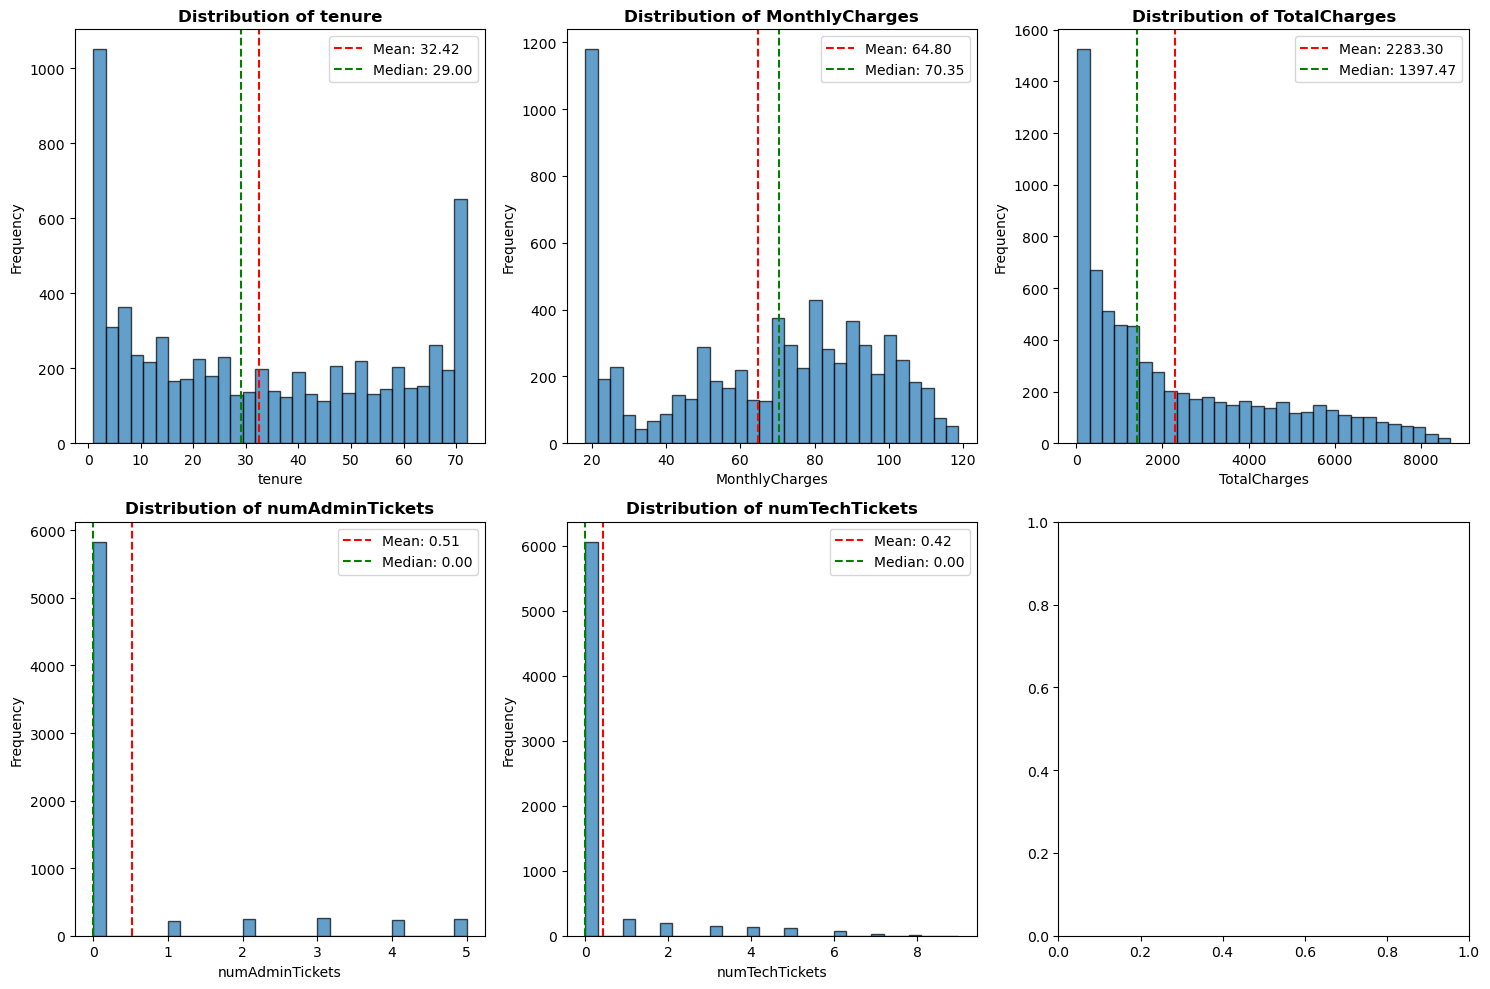

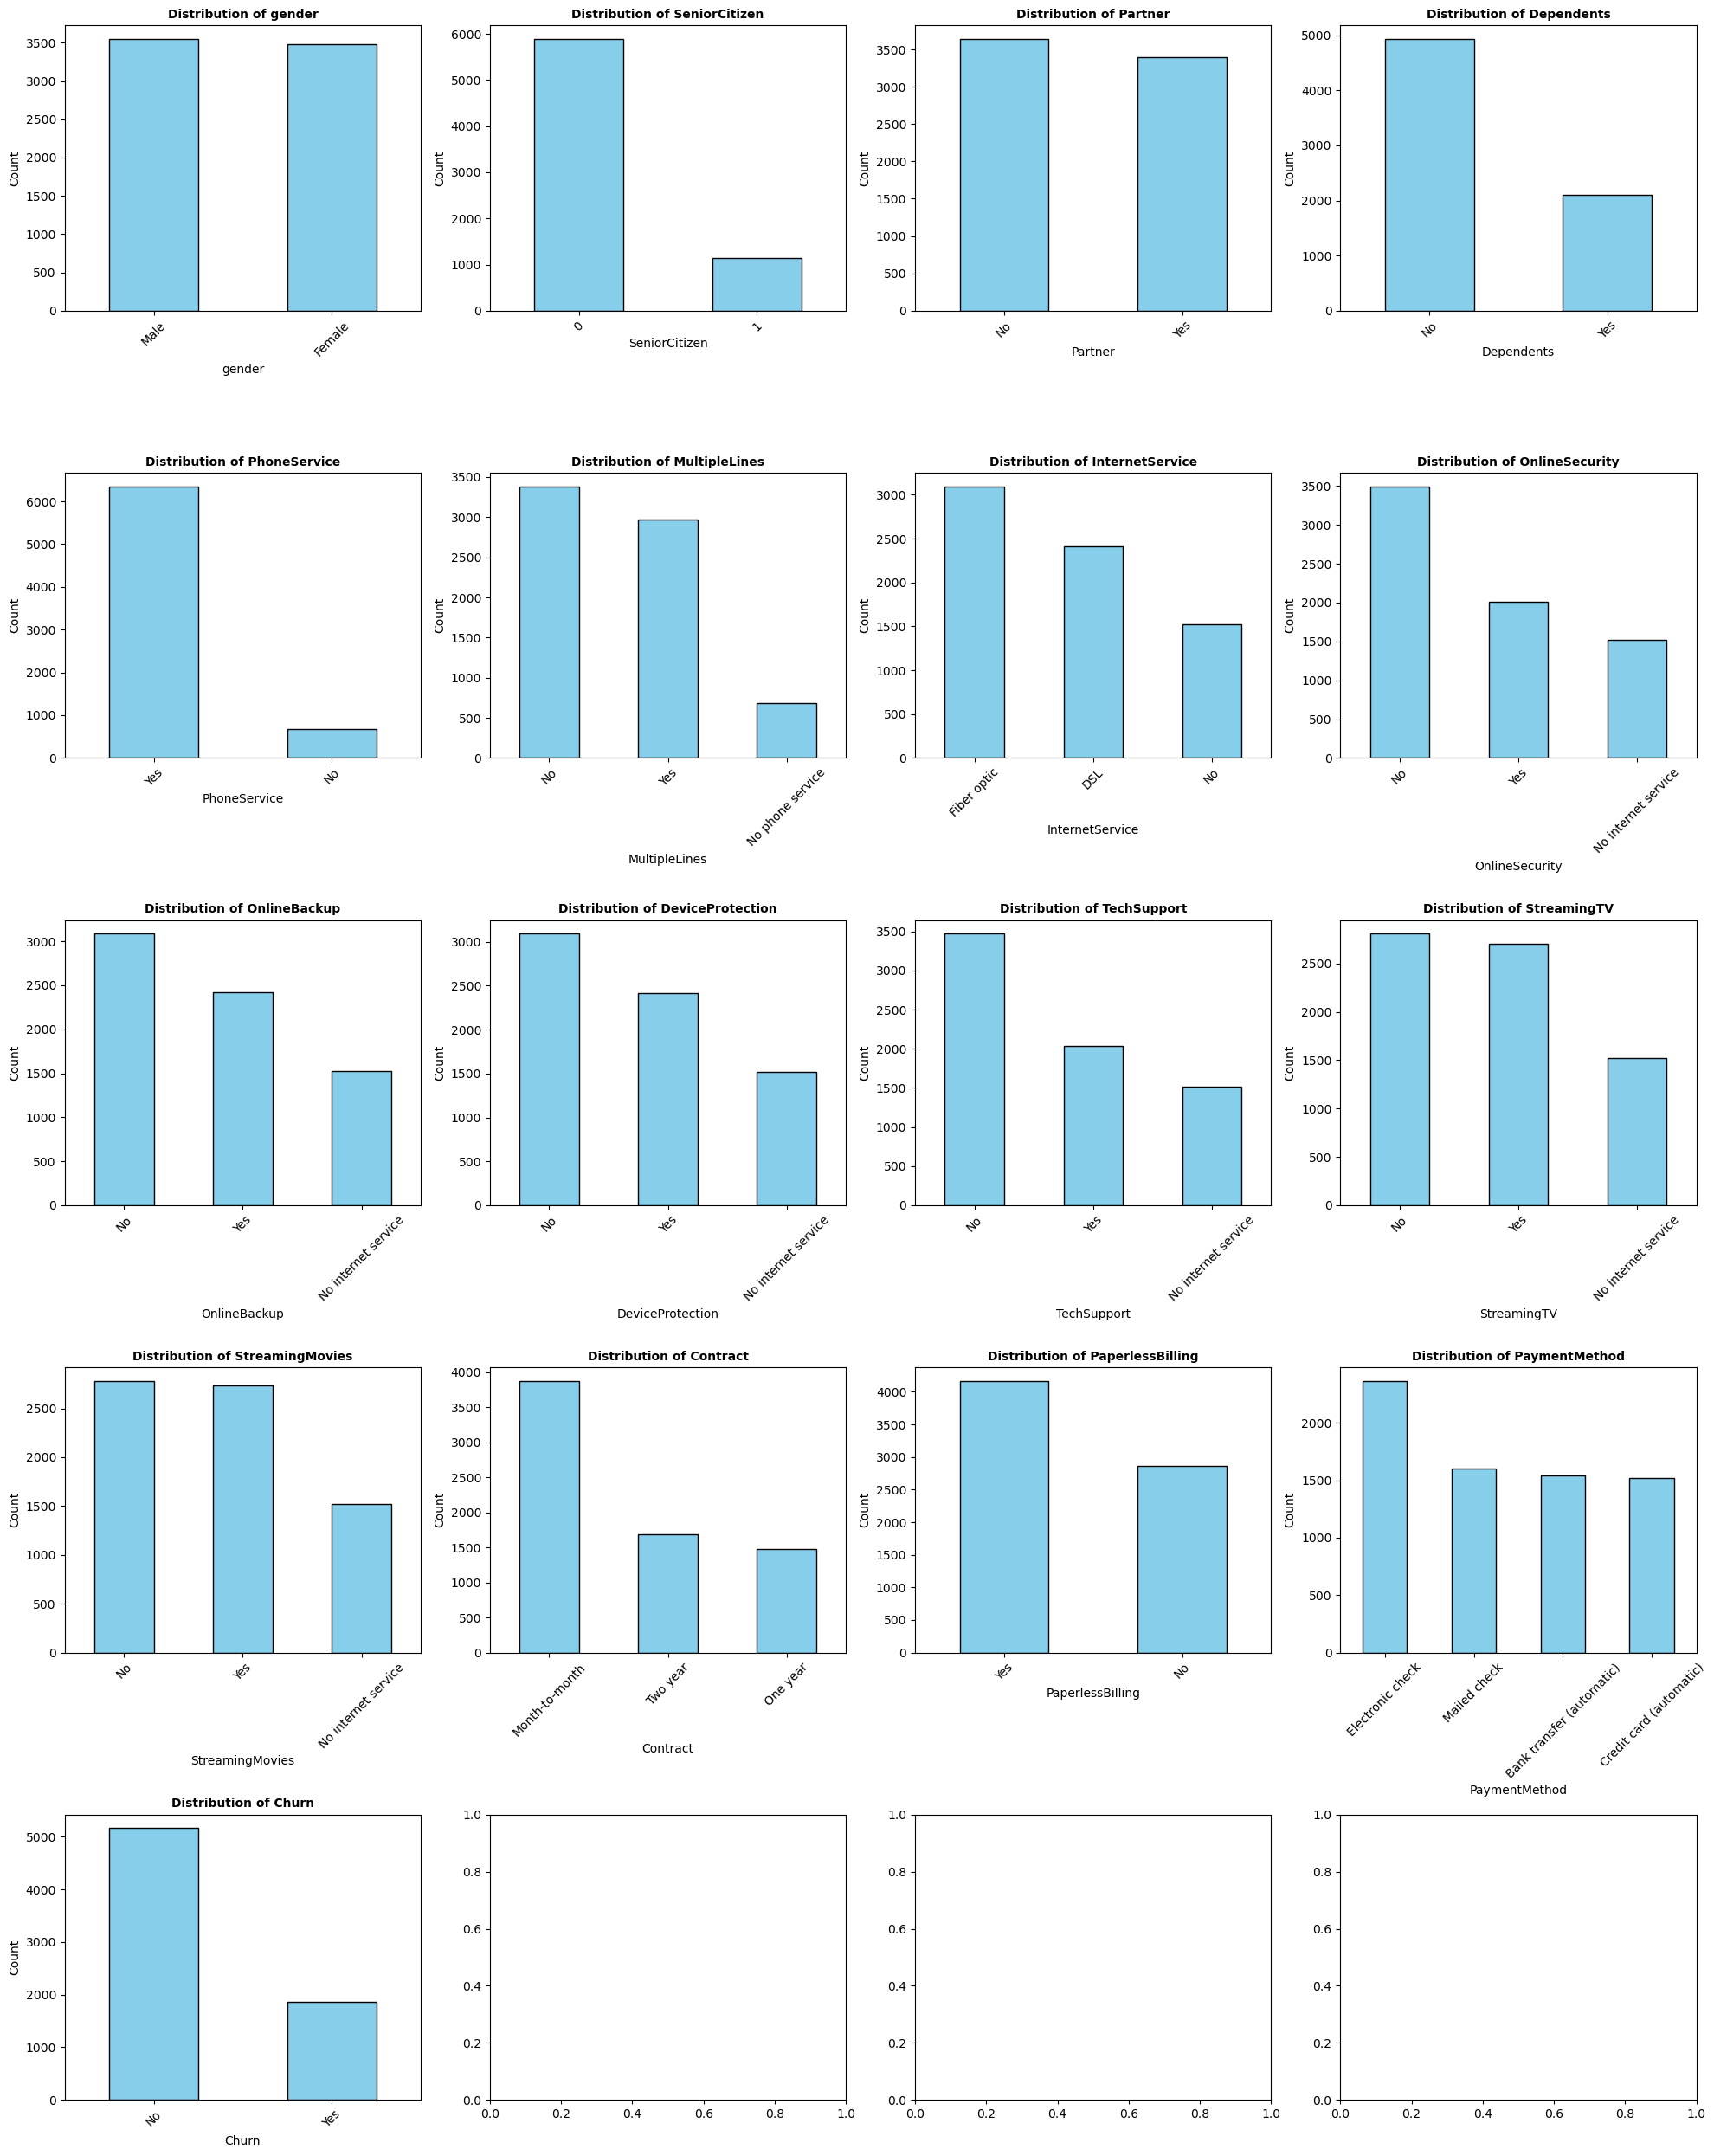

In [13]:
# Numerical features distribution
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 
                  'numAdminTickets', 'numTechTickets']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    if idx < len(numerical_cols):
        axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
        axes[idx].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.2f}')
        axes[idx].legend()

plt.tight_layout()
plt.show()

# Categorical features distribution
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 
                    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
                    'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

fig, axes = plt.subplots(5, 4, figsize=(20, 25))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    if idx < len(categorical_cols):
        df[col].value_counts().plot(kind='bar', ax=axes[idx], color='skyblue', edgecolor='black')
        axes[idx].set_title(f'Distribution of {col}', fontsize=10, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Count')
        axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

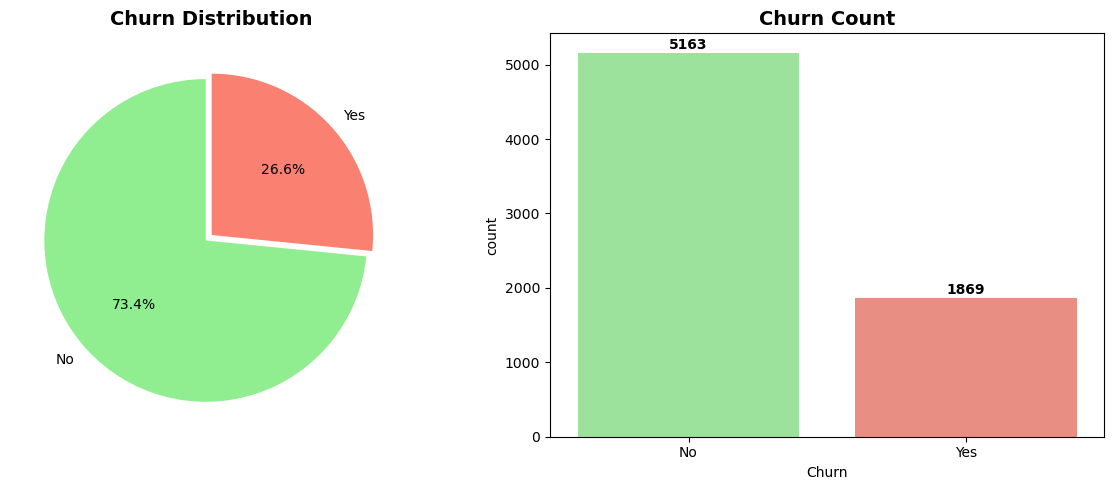

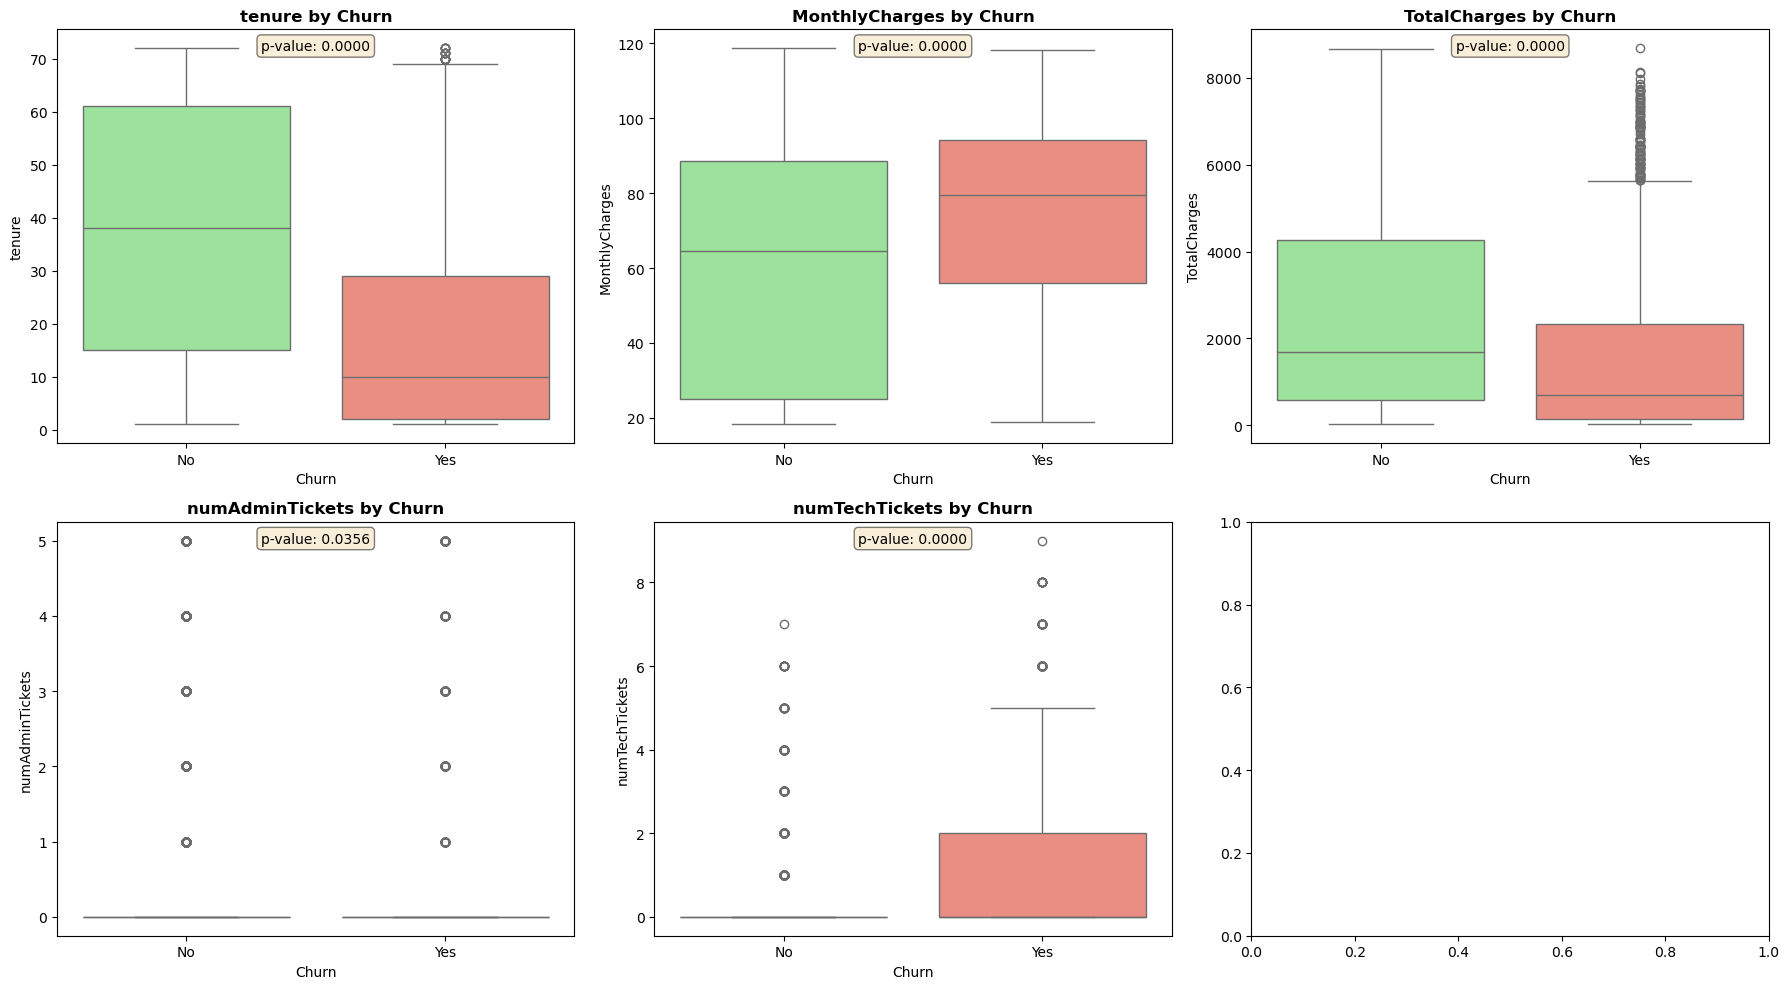

In [15]:
# Churn distribution
from scipy import stats
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', 
            colors=['lightgreen', 'salmon'], explode=(0.05, 0), startangle=90)
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')

# Bar plot
sns.countplot(data=df, x='Churn', ax=axes[1], palette=['lightgreen', 'salmon'])
axes[1].set_title('Churn Count', fontsize=14, fontweight='bold')
for i, v in enumerate(churn_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Numerical features vs Churn
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    if idx < len(numerical_cols):
        # Box plot
        sns.boxplot(data=df, x='Churn', y=col, ax=axes[idx], palette=['lightgreen', 'salmon'])
        axes[idx].set_title(f'{col} by Churn', fontsize=12, fontweight='bold')
        
        # Add statistical test
        churn_yes = df[df['Churn'] == 'Yes'][col]
        churn_no = df[df['Churn'] == 'No'][col]
        stat, p_value = stats.mannwhitneyu(churn_yes, churn_no, alternative='two-sided')
        axes[idx].text(0.5, 0.95, f'p-value: {p_value:.4f}', transform=axes[idx].transAxes, 
                      ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

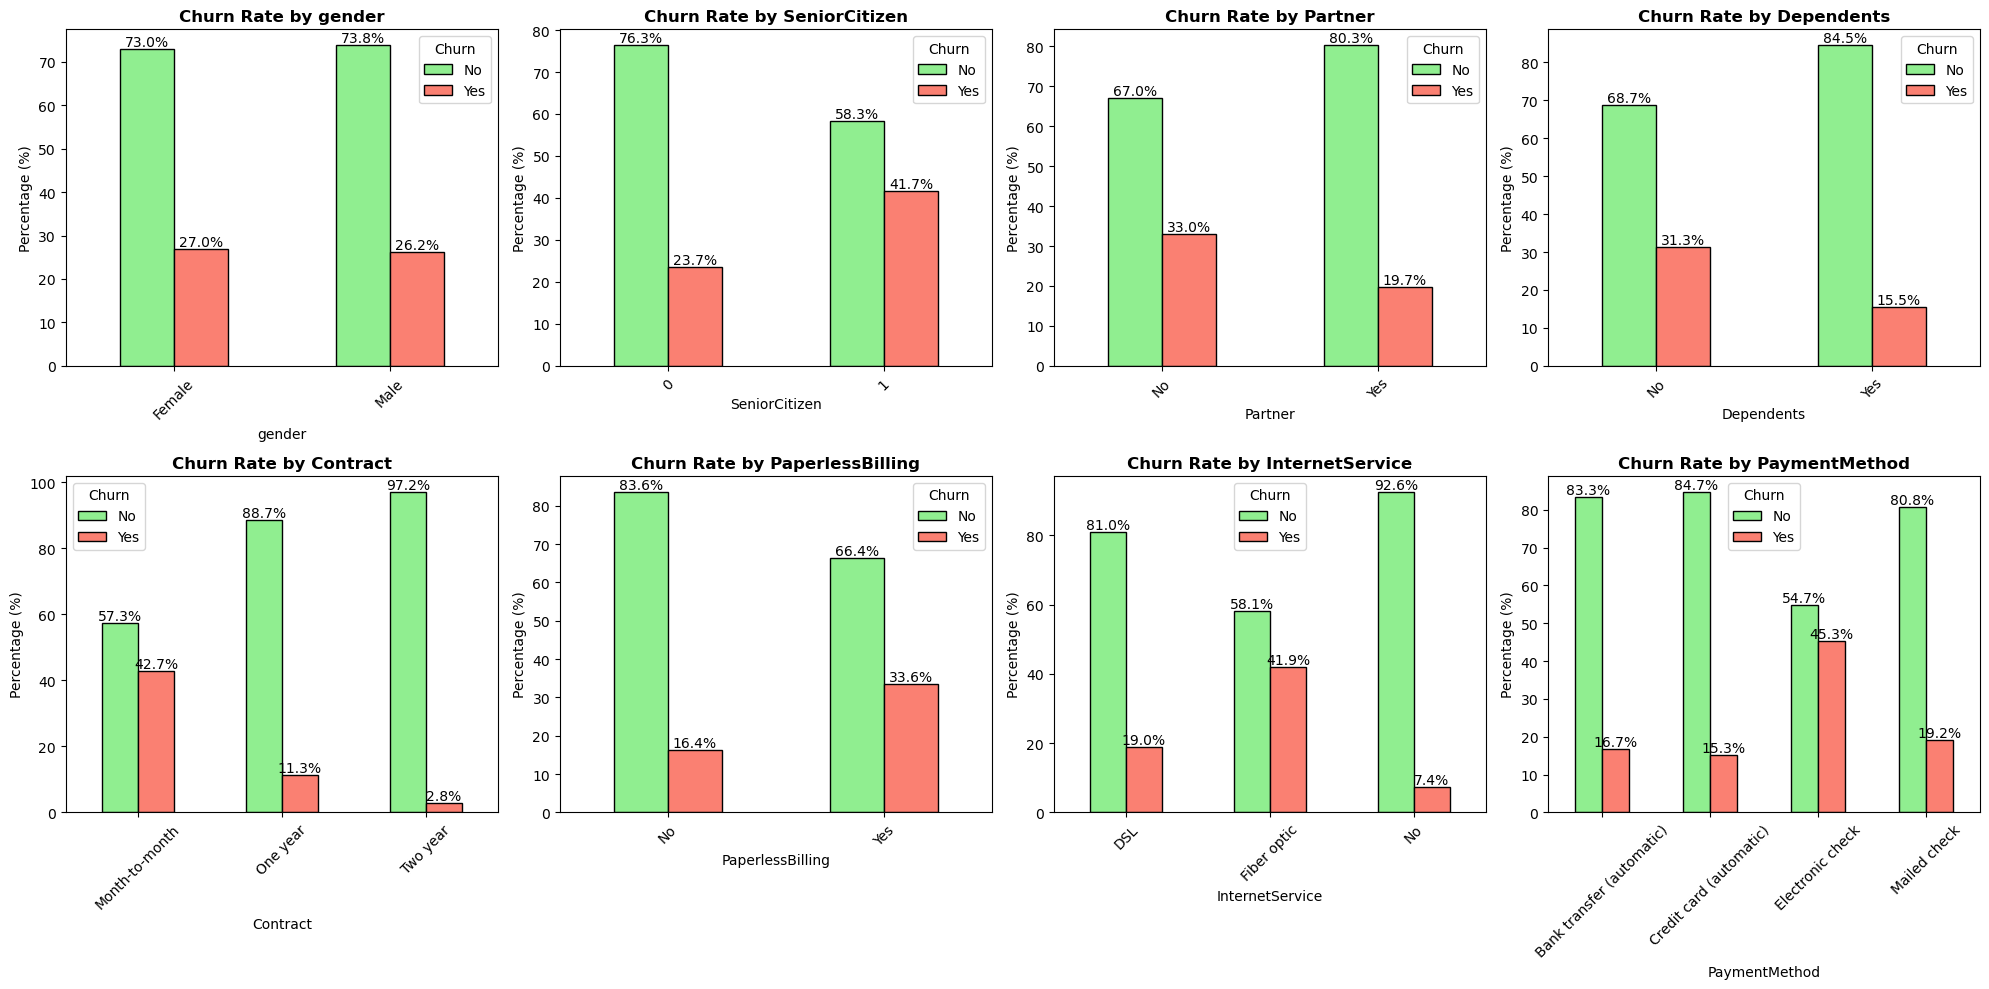

In [16]:
# Select categorical features for churn analysis
cat_churn_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Contract', 
                  'PaperlessBilling', 'InternetService', 'PaymentMethod']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, col in enumerate(cat_churn_cols):
    if idx < len(cat_churn_cols):
        # Create crosstab
        ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
        ct.plot(kind='bar', ax=axes[idx], color=['lightgreen', 'salmon'], edgecolor='black')
        axes[idx].set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Percentage (%)')
        axes[idx].set_xlabel(col)
        axes[idx].legend(title='Churn')
        axes[idx].tick_params(axis='x', rotation=45)
        
        # Add value labels
        for container in axes[idx].containers:
            axes[idx].bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

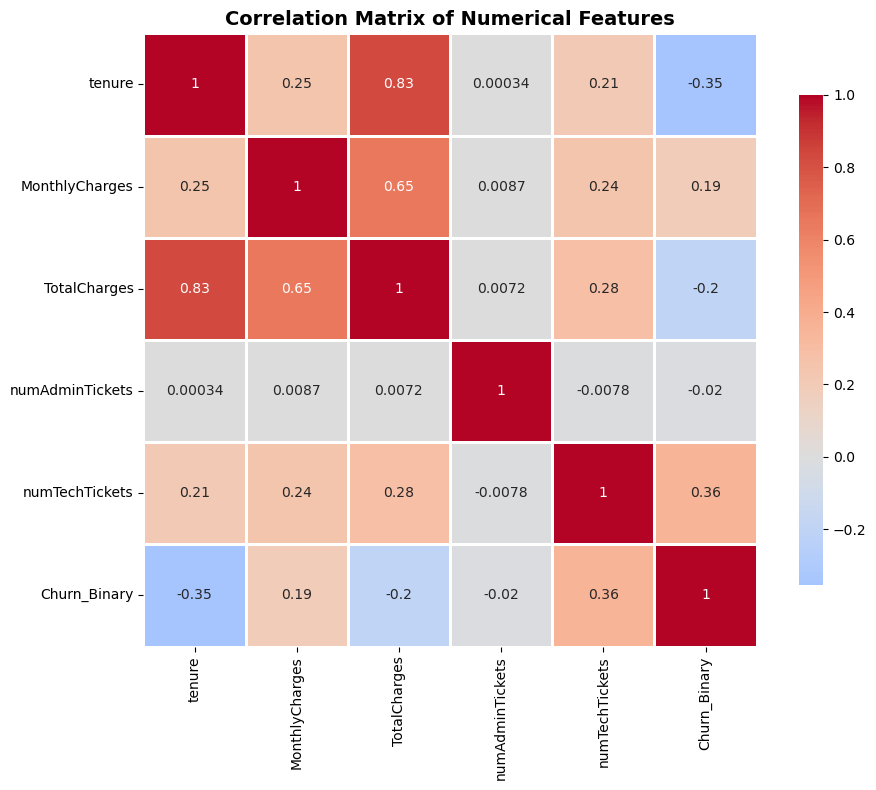


Top correlations with Churn:
Churn_Binary       1.000000
numTechTickets     0.357100
MonthlyCharges     0.192858
numAdminTickets   -0.019562
TotalCharges      -0.199484
tenure            -0.354049
Name: Churn_Binary, dtype: float64


In [17]:
# Correlation matrix for numerical features
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 
                      'numAdminTickets', 'numTechTickets', 'Churn_Binary']

correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top correlations with Churn
churn_corr = correlation_matrix['Churn_Binary'].sort_values(ascending=False)
print("\nTop correlations with Churn:")
print(churn_corr)

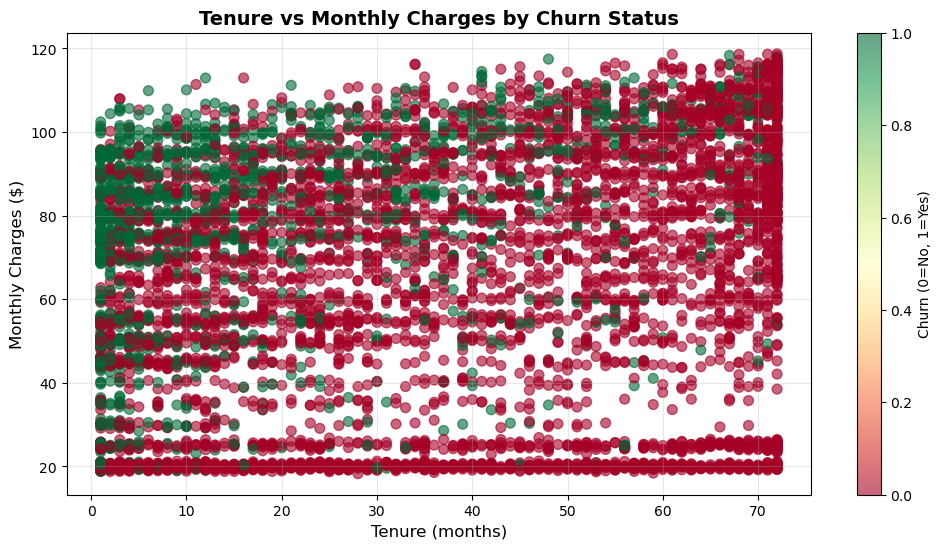

<Figure size 1000x600 with 0 Axes>

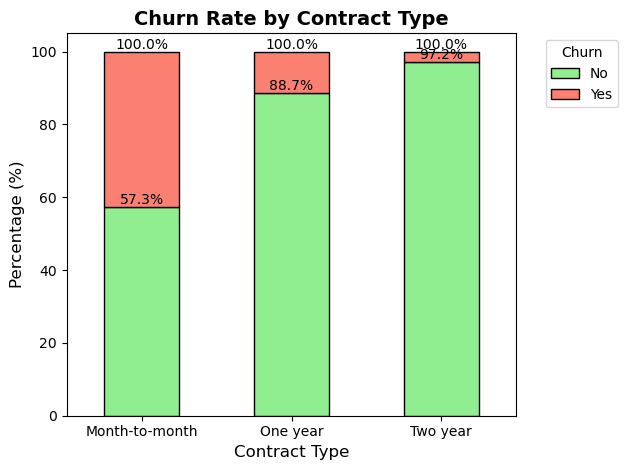

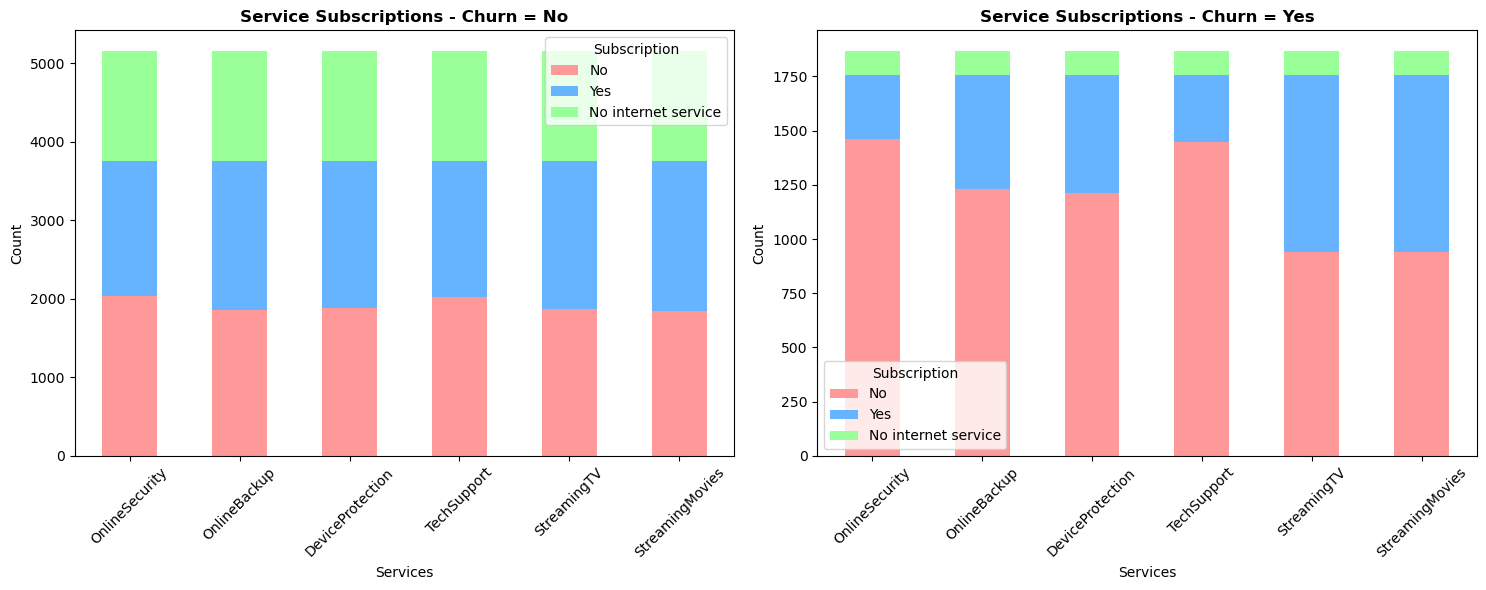

In [18]:
# 1. Tenure vs Monthly Charges colored by Churn
plt.figure(figsize=(12, 6))
scatter = plt.scatter(df['tenure'], df['MonthlyCharges'], 
                     c=df['Churn_Binary'], cmap='RdYlGn', alpha=0.6, s=50)
plt.colorbar(scatter, label='Churn (0=No, 1=Yes)')
plt.xlabel('Tenure (months)', fontsize=12)
plt.ylabel('Monthly Charges ($)', fontsize=12)
plt.title('Tenure vs Monthly Charges by Churn Status', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Contract type and Churn rate
plt.figure(figsize=(10, 6))
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=True, color=['lightgreen', 'salmon'], edgecolor='black')
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

# 3. Heatmap of service subscriptions by Churn
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for idx, churn_status in enumerate(['No', 'Yes']):
    subset = df[df['Churn'] == churn_status]
    service_matrix = pd.DataFrame()
    for service in service_cols:
        service_matrix[service] = subset[service].value_counts()
    
    service_matrix.T.plot(kind='bar', ax=axes[idx], stacked=True, 
                         color=['#ff9999','#66b3ff','#99ff99'])
    axes[idx].set_title(f'Service Subscriptions - Churn = {churn_status}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Services')
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].legend(title='Subscription')

plt.tight_layout()
plt.show()

In [19]:
# Generate summary insights
print("="*60)
print("KEY INSIGHTS FROM EDA")
print("="*60)

print(f"\n1. Overall Churn Rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.2f}%")

print("\n2. Churn Rate by Key Demographics:")
print(f"   - Senior Citizens: {df[df['SeniorCitizen']==1]['Churn'].value_counts(normalize=True)['Yes']*100:.2f}%")
print(f"   - With Partners: {df[df['Partner']=='Yes']['Churn'].value_counts(normalize=True)['Yes']*100:.2f}%")
print(f"   - With Dependents: {df[df['Dependents']=='Yes']['Churn'].value_counts(normalize=True)['Yes']*100:.2f}%")

print("\n3. Churn Rate by Contract:")
for contract in df['Contract'].unique():
    rate = df[df['Contract']==contract]['Churn'].value_counts(normalize=True).get('Yes', 0)*100
    print(f"   - {contract}: {rate:.2f}%")

print("\n4. Average Values by Churn Status:")
print(f"   - Tenure (months): Churn={df[df['Churn']=='Yes']['tenure'].mean():.1f} | No Churn={df[df['Churn']=='No']['tenure'].mean():.1f}")
print(f"   - Monthly Charges: Churn=${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f} | No Churn=${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")
print(f"   - Total Charges: Churn=${df[df['Churn']=='Yes']['TotalCharges'].mean():.2f} | No Churn=${df[df['Churn']=='No']['TotalCharges'].mean():.2f}")
print(f"   - Admin Tickets: Churn={df[df['Churn']=='Yes']['numAdminTickets'].mean():.2f} | No Churn={df[df['Churn']=='No']['numAdminTickets'].mean():.2f}")
print(f"   - Tech Tickets: Churn={df[df['Churn']=='Yes']['numTechTickets'].mean():.2f} | No Churn={df[df['Churn']=='No']['numTechTickets'].mean():.2f}")
print("\n" + "="*60)
print("EDA COMPLETED SUCCESSFULLY!")
print("="*60)

KEY INSIGHTS FROM EDA

1. Overall Churn Rate: 26.58%

2. Churn Rate by Key Demographics:
   - Senior Citizens: 41.68%
   - With Partners: 19.72%
   - With Dependents: 15.53%

3. Churn Rate by Contract:
   - Month-to-month: 42.71%
   - One year: 11.28%
   - Two year: 2.85%

4. Average Values by Churn Status:
   - Tenure (months): Churn=18.0 | No Churn=37.7
   - Monthly Charges: Churn=$74.44 | No Churn=$61.31
   - Total Charges: Churn=$1531.80 | No Churn=$2555.34
   - Admin Tickets: Churn=0.47 | No Churn=0.53
   - Tech Tickets: Churn=1.16 | No Churn=0.15

EDA COMPLETED SUCCESSFULLY!


In [20]:
df.to_csv('cleaned_customer_data.csv', index=False)
print(" Data saved as 'cleaned_customer_data.csv'")

 Data saved as 'cleaned_customer_data.csv'


In [22]:
print(df.head(20))

    customerID  gender SeniorCitizen Partner Dependents  tenure PhoneService  \
0   7590-VHVEG  Female             0     Yes         No       1           No   
1   5575-GNVDE    Male             0      No         No      34          Yes   
2   3668-QPYBK    Male             0      No         No       2          Yes   
3   7795-CFOCW    Male             0      No         No      45           No   
4   9237-HQITU  Female             0      No         No       2          Yes   
5   9305-CDSKC  Female             0      No         No       8          Yes   
6   1452-KIOVK    Male             0      No        Yes      22          Yes   
7   6713-OKOMC  Female             0      No         No      10           No   
8   7892-POOKP  Female             0     Yes         No      28          Yes   
9   6388-TABGU    Male             0      No        Yes      62          Yes   
10  9763-GRSKD    Male             0     Yes        Yes      13          Yes   
11  7469-LKBCI    Male             0    